In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
price_data = pd.read_csv(
    "../data/prices.csv",
    index_col=0,
    parse_dates=True
)

returns = np.log(price_data).diff().dropna()
returns.head()


,AAPL,MSFT
Date,,
2020-01-03,-0.009770,-0.012530
2020-01-06,0.007937,0.002581
2020-01-07,-0.004714,-0.009159
2020-01-08,0.015959,0.015803
2020-01-09,0.021018,0.012416


In [6]:
# Correlation matrix
returns.corr()
# Recall : Shows correlation coeffiecients between 2 variables 

,AAPL,MSFT
AAPL,1.000000,0.779637
MSFT,0.779637,1.000000


In [5]:
# Covariance matrix
returns.cov()
# Covariance matrix shows how 2 variables move together

,AAPL,MSFT
AAPL,0.000447,0.000339
MSFT,0.000339,0.000423


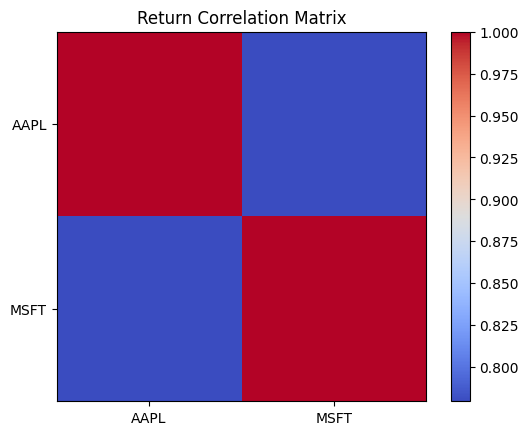

In [10]:
# Visualise the correlation
plt.imshow(returns.corr(), cmap = "coolwarm")
plt.colorbar()
plt.xticks(range(len(returns.columns)), returns.columns)
plt.yticks(range(len(returns.columns)), returns.columns)
plt.title("Return Correlation Matrix")
plt.show()

In [13]:
window = 60 # 60 trading days

rolling_corr = (
    returns["AAPL"].rolling(window).corr(returns["MSFT"])
)
# Works out the correlation between AAPL and MSFT returns over the past trading 60 days

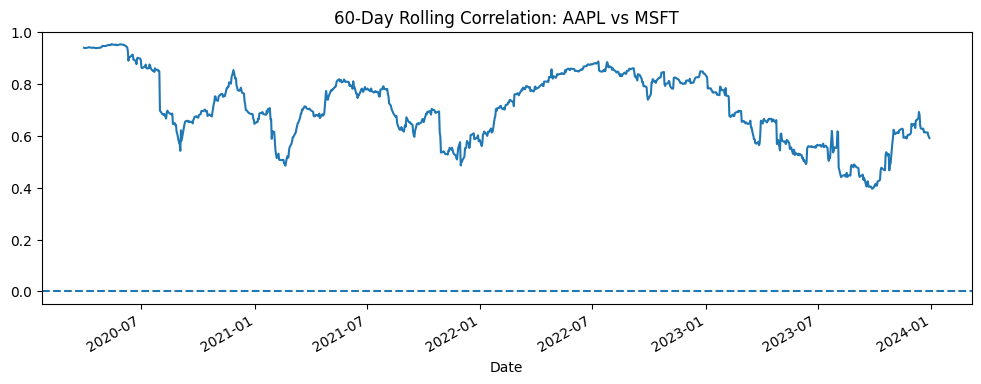

In [16]:
# Plot rolling correlation
rolling_corr.plot(figsize = (12,4))
plt.title("60-Day Rolling Correlation: AAPL vs MSFT") 
plt.axhline(0, linestyle = "--") # plot a dashed line at y = 0
plt.show()

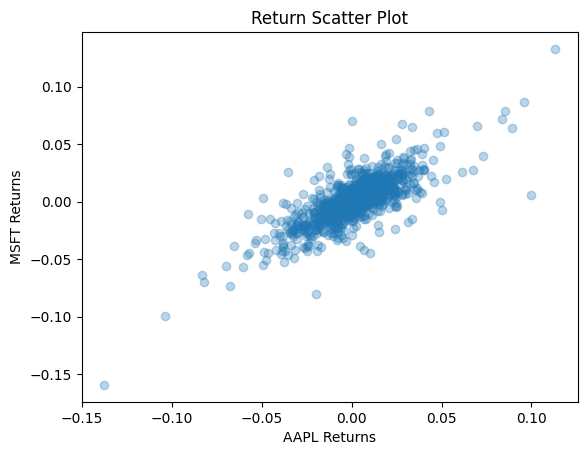

In [18]:
plt.scatter(returns["AAPL"], returns["MSFT"], alpha=0.3)
plt.xlabel("AAPL Returns")
plt.ylabel("MSFT Returns")
plt.title("Return Scatter Plot")
plt.show()
# Scatter graph shows high correlation due to shape, but high corelation doesn't mean mean-reverting spread (ie doesn't oscillate around a horizontal line)
